# ForceSMIP Challenge Analysis - Refactored

This notebook demonstrates the ForceSMIP analysis using the new encapsulated modules.

## 1. Setup and Imports

In [1]:
import sys
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

# Add src to path
sys.path.append(os.path.join(os.getcwd(), "ForceSMIP"))

# Import our modules
from data_loader import ForceSMIPDataLoader, yearly_average, compute_yearly_average_dict
from preprocessing import (
    merge_training_data, reshape_training_data, 
    apply_notnan_filter_complete
)
from algorithms import WeightedRidgeRegression, ridge_regression, LowRankSolver
from evaluation import ForceSMIPEvaluator, compute_trends_from_data, compute_statistics
from visualization import ForceSMIPVisualizer
from forcesmip_pipeline import ForceSMIPPipeline

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Modules loaded successfully!")


Modules loaded successfully!


## 2. Quick Start - Complete Pipeline

In [2]:
# Initialize pipeline
base_path = '/net/krypton/climdyn_nobackup/FTP'

# variable names: pr, prmax, psl, tas, tos, tasmax, tasmin, zmta
variable = 'psl'  # Sea Level Pressure

pipeline = ForceSMIPPipeline(base_path, variable=variable)
print(f"Pipeline initialized for variable: {variable}")

Pipeline initialized for variable: psl


In [3]:
# # Run complete analysis with default parameters
# summary = pipeline.run_complete_analysis(
#     lambda_reg=2500.0,     # Ridge regression regularization
#     rank=10,               # Low-rank approximation rank
#     apply_smoothing=False  # Whether to apply temporal smoothing
# )

# print("\n=== Analysis Complete! ===")

In [4]:
# # Display performance summary
# print("\n=== Performance Summary ===")
# for method, metrics in summary.items():
#     print(f"\n{method}:")
#     print(f"  Mean NRMSE: {metrics['mean_nrmse']:.4f}")
#     print(f"  Mean Pattern Correlation: {metrics['mean_pattern_corr']:.4f}")
#     print(f"  Worst NRMSE: {metrics['worst_nrmse']:.4f}")

In [5]:
# import netCDF4 as nc

# file_path = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP/Training-Ext/Amon/zmta/CanESM5/zmta_mon_CanESM5_historical_ssp585_r7i1p2f1.188001-210012.nc'

# with nc.Dataset(file_path, 'r') as nc_file:
#     print(nc_file.variables.keys())

#     time = np.array(nc_file.variables['time'])

#     data = np.array(nc_file.variables['ta'])

# print(data[np.isnan(data)==True].shape)
# print(data.shape)
# data_tmp = data.copy()
# data_tmp[np.abs(data_tmp) > 1e9] = np.nan  # Handle missing values
# print(data_tmp[np.isnan(data_tmp)==True].shape)
# # Monthly centering
# for i in range(12):
#     month_mask = np.arange(time.shape[0]) % 12 == i
#     monthly_mean = np.nanmean(data_tmp[month_mask, :, :], axis=0)
#     data[month_mask, :, :] -= monthly_mean




## 3. Step-by-Step Analysis (Manual Pipeline)

### 3.1 Data Loading

In [6]:
# Initialize data loader
data_loader = ForceSMIPDataLoader(base_path)

# Load training data
print("Loading training data...")
dic_data, dic_forced_response, longitude, latitude = data_loader.load_training_data(variable)

print(f"Training data loaded:")
print(f"  Number of models: {len(dic_data)}")
print(f"  Model names: {list(dic_data.keys())}")
print(f"  Grid shape: {latitude.shape[0]} x {longitude.shape[0]}")
print(f"  Time steps: {list(dic_data.values())[0].shape[1]}")

Loading training data...
Processing 1/5: CESM2
  Processing 1/50: psl_mon_CESM2_historical_ssp370_r1251.013i1p1f1.188001-210012.nc
  Processing 2/50: psl_mon_CESM2_historical_ssp370_r1011.001i1p1f1.188001-210012.nc
  Processing 3/50: psl_mon_CESM2_historical_ssp370_r1251.015i1p1f1.188001-210012.nc
  Processing 4/50: psl_mon_CESM2_historical_ssp370_r1031.002i1p1f1.188001-210012.nc
  Processing 5/50: psl_mon_CESM2_historical_ssp370_r1251.014i1p1f1.188001-210012.nc
  Processing 6/50: psl_mon_CESM2_historical_ssp370_r1051.003i1p1f1.188001-210012.nc
  Processing 7/50: psl_mon_CESM2_historical_ssp370_r1251.016i1p1f1.188001-210012.nc
  Processing 8/50: psl_mon_CESM2_historical_ssp370_r1071.004i1p1f1.188001-210012.nc
  Processing 9/50: psl_mon_CESM2_historical_ssp370_r1251.017i1p1f1.188001-210012.nc
  Processing 10/50: psl_mon_CESM2_historical_ssp370_r1091.005i1p1f1.188001-210012.nc
  Processing 11/50: psl_mon_CESM2_historical_ssp370_r1251.018i1p1f1.188001-210012.nc
  Processing 12/50: psl_mon

In [9]:
# Load test data
test_models = ['1A','1B','1C','1D','1E','1F','1G','1J']
print("\nLoading test data...")
data_test, temporal_means = data_loader.load_test_data(variable, tier= 'Tier1',test_models=test_models)
data_ground_truth = data_loader.load_ground_truth(variable,test_models=test_models)
data_estimates = data_loader.load_estimates(variable, test_models=test_models)

test_models_tmp = range(1, 11)

print(f"Test data shape: {data_test.shape}")
print(f"Ground truth shape: {data_ground_truth.shape}")
print(f"Estimates shape: {data_estimates.shape}")


Loading test data...
Files in test data directory: ['psl_mon_1A.195001-202212.nc', 'psl_mon_1B.195001-202212.nc', 'psl_mon_1C.195001-202212.nc', 'psl_mon_1D.195001-202212.nc', 'psl_mon_1E.195001-202212.nc', 'psl_mon_1F.195001-202212.nc', 'psl_mon_1G.195001-202212.nc', 'psl_mon_1H.195001-202212.nc', 'psl_mon_1I.195001-202212.nc', 'psl_mon_1J.195001-202212.nc']
Loading test data for 1A at index 0
create data_test array
Monthly centering
Loading test data for 1B at index 1
Monthly centering
Loading test data for 1C at index 2
Monthly centering
Loading test data for 1D at index 3
Monthly centering
Loading test data for 1E at index 4
Monthly centering
Loading test data for 1F at index 5
Monthly centering
Loading test data for 1G at index 6
Monthly centering
Loading test data for 1J at index 7
Monthly centering
Loading ground truth for 1A at index 0
Loading ground truth for 1B at index 1
Loading ground truth for 1C at index 2
Loading ground truth for 1D at index 3
Loading ground truth for 1

### 3.2 Data Preprocessing

In [10]:
# Compute yearly averages
print("Computing yearly averages...")
dic_data_yearly = compute_yearly_average_dict(dic_data)
dic_forced_response_yearly = compute_yearly_average_dict(dic_forced_response)

data_test_yearly = yearly_average(data_test)
data_ground_truth_yearly = yearly_average(data_ground_truth)

print(f"Yearly data shape (first model): {list(dic_data_yearly.values())[0].shape}")
print(f"Test yearly shape: {data_test_yearly.shape}")

Computing yearly averages...
Yearly data shape (first model): (50, 221, 72, 144)
Test yearly shape: (8, 73, 72, 144)


In [11]:
# Prepare training data for machine learning
print("Preparing training data...")

# Method 1: Merge all training data
x_train_merged, y_train_merged = merge_training_data(
    dic_data_yearly, dic_forced_response_yearly
)

# Method 2: Keep model separation
x_train_dict, y_train_dict = reshape_training_data(
    dic_data_yearly, dic_forced_response_yearly
)

print(f"Merged training data shape: X={x_train_merged.shape}, Y={y_train_merged.shape}")
print(f"Separated training data: {len(x_train_dict)} models")

Preparing training data...
Merged training data shape: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Separated training data: 5 models


### 3.3 Data Smoothing (Optional)

In [12]:
def capture_nans(x_train_dict):
    """
    Capture indices of NaN values across all training data.
    Args:
        x_train_dict (dict): Dictionary of training data tensors with keys as model names.
    Returns:
        nan_union (list): List of indices where NaN values are found across all models.
        notnan_inter (list): List of indices where no NaN values are found across all models.
    """
    
    # enumerate in the dictionary and get the union of the nans for each pair ((key, value))
    for (key, value) in x_train_dict.items():
        # nan_indices = list(torch.where(torch.abs(value[0,:,:]) > 1e9)[0].numpy())

        # new code to test 
        # get nan mask of test set 
        
        # nan_mask = np.where(np.abs(value[0,:,:])>1e9, True, False)
        nan_mask = np.where(np.isnan(value[0,:,:])==True, True, False)

        
        # get the index of columns where there is at least one True in the nan mask
        
        col_indices = np.where(np.any(nan_mask, axis=0))[0]


        if 'nan_union' not in locals():
            nan_union = col_indices
        else:
            nan_union = list(set(nan_union) | set(col_indices))

    notnan_inter = list(set(range(value.shape[2])) - set(nan_union))

    return nan_union, notnan_inter

In [13]:
nan_idx, notnan_idx =capture_nans(x_train_dict)

# Prepare test data for smoothing experiments
x_test = torch.from_numpy(data_test.reshape(
    data_test.shape[0], data_test.shape[1], -1
)).to(torch.float32)

print(f"Test data shape for smoothing: {x_test.shape}")

Test data shape for smoothing: torch.Size([8, 876, 10368])


/tmp/ipykernel_5217/526104507.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  nan_mask = np.where(np.isnan(value[0,:,:])==True, True, False)


In [14]:
# add the nans that are also included in the test data
# record nan indices as the union of nans on each map
nan_idx_test = nan_idx.copy()

for idx_r in range(x_test.shape[0]):

    # get nan mask of test set 
    # nan_mask = np.where(np.abs(x_test[idx_r,:,:])>1e9, True, False)
    nan_mask = np.where(np.isnan(x_test[idx_r,:,:])==True, True, False)

    # get the index of columns where there is at least one True in the nan mask
    col_indices = np.where(np.any(nan_mask, axis=0))[0]

    nan_idx_test = list(set(nan_idx_test) | set(col_indices))    

# define not nan indices (useful to ease the computations)
notnan_idx_test = list(set(list(range(x_test.shape[2]))) - set(nan_idx_test))

# replace the nan index by Nans
notnan_idx = notnan_idx_test
nan_idx = nan_idx_test

/tmp/ipykernel_5217/3558715273.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  nan_mask = np.where(np.isnan(x_test[idx_r,:,:])==True, True, False)


In [15]:
# Apply not-NaN filter to all data
x_train_merged_filtered, y_train_merged_filtered, \
x_train_dict_filtered, y_train_dict_filtered, x_test_filtered = apply_notnan_filter_complete(
    x_train_merged, y_train_merged,
    x_train_dict, y_train_dict,
    x_test, notnan_idx_test
)

              APPLYING NOT-NAN FILTER TO ALL DATA
Valid indices count: 10368

1. Filtering merged training data...


   X: torch.Size([40885, 10368]) -> torch.Size([40885, 10368])
   Y: torch.Size([40885, 10368]) -> torch.Size([40885, 10368])

2. Filtering training dictionaries...
Filtering training dictionaries...
Keeping 10368 valid spatial features
CESM2: X torch.Size([50, 221, 10368]) -> torch.Size([50, 221, 10368])
CanESM5: X torch.Size([25, 221, 10368]) -> torch.Size([25, 221, 10368])
MIROC-ES2L: X torch.Size([30, 221, 10368]) -> torch.Size([30, 221, 10368])
MIROC6: X torch.Size([50, 221, 10368]) -> torch.Size([50, 221, 10368])
MPI-ESM1-2-LR: X torch.Size([30, 221, 10368]) -> torch.Size([30, 221, 10368])

3. Filtering test data...
   Test: torch.Size([8, 876, 10368]) -> torch.Size([8, 876, 10368])

=== FILTERING SUMMARY ===
Original spatial features: 10368
Filtered spatial features: 10368
Features removed: 0
Reduction: 0.0%


### 3.4 Model Training

##### TO DO
##### compute the surface area and use it in the penalty
##### display the maps for each line
##### compute the robust results on the training set

In [16]:
# build a weight matrix (latitude, longitude) where each grid cell is weighted by its surface area
# weights = np.cos(np.radians(latitude))

# # duplicate weights for each longitude
# surface = torch.from_numpy(np.tile(weights[:, np.newaxis], (1, longitude.shape[0]))).to(torch.float32).flatten()
# # surface = torch.ones(surface.shape[0])
# surface = surface[notnan_idx]

In [17]:
# Updated cell for model training
# Train global ridge regression model
lambda_reg = 200000.0
# print(f"Training ridge regression with lambda={lambda_reg}...")

w_ridge = ridge_regression(x_train_merged_filtered,y_train_merged_filtered, lambda_reg, surface=None, verbose=True)
print(f"Ridge weights shape: {w_ridge.shape}")

Solving ridge regression with λ=200000.0
Input shape: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Reshaped: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Ridge weights computed: torch.Size([10368, 10368])
Ridge weights shape: torch.Size([10368, 10368])


In [19]:
# Setup low-rank solver for efficient multiple rank solutions
print(f"\nSetting up low-rank solver...")
lr_solver = LowRankSolver()
lr_solver.W_full = w_ridge
lr_solver.fit(x_train_merged_filtered, y_train_merged_filtered, lambda_reg,surface=None, verbose=True)

# Get solutions for multiple ranks efficiently
ranks_to_test = [2, 5, 10, 15, 20, 25, 30]
rank_solutions = lr_solver.get_multiple_ranks(ranks_to_test, verbose=True)

# Print explained variance for different ranks
print(f"\nExplained variance by rank:")
cumulative_var = lr_solver.cumulative_variance_ratio()
for rank in ranks_to_test:
    if rank <= len(cumulative_var):
        print(f"  Rank {rank}: {cumulative_var[rank-1]:.4f}")

# Use the primary rank solution
primary_rank = 10
w_ridge_lr = rank_solutions[primary_rank]
print(f"Primary rank-{primary_rank} weights shape: {w_ridge_lr.shape}")


Setting up low-rank solver...
Computing SVD for low-rank approximations...
SVD computed: U=torch.Size([51253, 10368]), S=torch.Size([10368]), Vt=torch.Size([10368, 10368])
Singular values range: 0.000491 to 294082.000000
Computed solutions for ranks: [2, 5, 10, 15, 20, 25, 30]

Explained variance by rank:
  Rank 2: 0.9426
  Rank 5: 0.9888
  Rank 10: 0.9975
  Rank 15: 0.9986
  Rank 20: 0.9990
  Rank 25: 0.9993
  Rank 30: 0.9995
Primary rank-10 weights shape: torch.Size([10368, 10368])


In [20]:
# # do some smoothing
from preprocessing import moving_average_smoothing

x_test_smooth = moving_average_smoothing(x_test_filtered, window_size=12*10, mode='same')

In [21]:
# Make predictions using different methods
print("Making predictions...")

# Global models
y_pred_ridge = x_test_filtered @ w_ridge
y_pred_ridge_lr = x_test_filtered @ w_ridge_lr

y_pred_ridge_smooth = x_test_smooth @ w_ridge
y_pred_ridge_lr_smooth = x_test_smooth @ w_ridge_lr

Making predictions...


In [22]:
# Initialize evaluator
evaluator = ForceSMIPEvaluator()

# Convert predictions to yearly averages and compute trends
def to_yearly_and_trends(pred_data, trend_years=slice(30, None)):
    """Helper function to convert monthly to yearly and compute trends."""
    pred_numpy = pred_data.cpu().numpy() if isinstance(pred_data, torch.Tensor) else pred_data
    pred_yearly = pred_numpy.reshape(pred_numpy.shape[0], pred_numpy.shape[1] // 12, 12, pred_numpy.shape[2])
    pred_yearly = np.nanmean(pred_yearly, axis=2)
    return compute_trends_from_data(pred_yearly, trend_years)

# Compute trends for all predictions
trend_years = slice(30, None)  # Last 43 years for trend computation

# reshape the data ground truth for trend computation
data_ground_truth_yearly = data_ground_truth_yearly.reshape(
    data_ground_truth_yearly.shape[0], 
    data_ground_truth_yearly.shape[1],
    -1
)

trends_ground_truth = compute_trends_from_data(data_ground_truth_yearly, trend_years)
trends_ridge = to_yearly_and_trends(y_pred_ridge, trend_years)
trends_ridge_smooth = to_yearly_and_trends(y_pred_ridge_smooth, trend_years)
trends_ridge_lr = to_yearly_and_trends(y_pred_ridge_lr, trend_years)
trends_ridge_lr_smooth = to_yearly_and_trends(y_pred_ridge_lr_smooth, trend_years)

print(f"Trends computed for {trends_ground_truth.shape[0]} test cases")
print(f"Trend groundtruth shape: {trends_ground_truth.shape}")
print(f"Trend shape: {trends_ridge.shape}")

Trends computed for 8 test cases
Trend groundtruth shape: (8, 10368)
Trend shape: (8, 10368)


In [23]:
# Evaluate all methods
predictions_dict = {
    'Ridge': trends_ridge,
    'Ridge + Low-rank': trends_ridge_lr,
    'Ridge + Smoothing': trends_ridge_smooth,
    'Ridge + Low-rank + Smoothing': trends_ridge_lr_smooth
}

comparison_results = evaluator.compare_methods(predictions_dict, trends_ground_truth[:, notnan_idx])

print("\n=== Method Comparison ===")
for method, results in comparison_results.items():
    print(f"\n{method}:")
    print(f"  Mean NRMSE: {results['mean_nrmse']:.4f}")
    print(f"  Mean Pattern Corr: {results['mean_pattern_corr']:.4f}")
    print(f"  Worst NRMSE: {results['worst_nrmse']:.4f}")
    print(f"  NRMSE Variance: {results['variance_nrmse']:.4f}")


=== Method Comparison ===

Ridge:
  Mean NRMSE: 0.4650
  Mean Pattern Corr: 0.9199
  Worst NRMSE: 0.7354
  NRMSE Variance: 0.0340

Ridge + Low-rank:
  Mean NRMSE: 0.4734
  Mean Pattern Corr: 0.9173
  Worst NRMSE: 0.7264
  NRMSE Variance: 0.0310

Ridge + Smoothing:
  Mean NRMSE: 0.4761
  Mean Pattern Corr: 0.9167
  Worst NRMSE: 0.7546
  NRMSE Variance: 0.0381

Ridge + Low-rank + Smoothing:
  Mean NRMSE: 0.4844
  Mean Pattern Corr: 0.9139
  Worst NRMSE: 0.7463
  NRMSE Variance: 0.0350


# Evaluate the weighted ridge regression

In [24]:
# Initialize visualizer
visualizer = ForceSMIPVisualizer(longitude, latitude, range(w_ridge.shape[0]))

# # we need to know the latitude and longitude size
# lat_size = latitude.shape[0]
# lon_size = longitude.shape[0]


# # Convert to numpy array for plotting
# w_ridge_np = w_ridge.cpu().numpy()

# Reshape each row of w_ridge to match the map dimensions
# w_ridge_maps = w_ridge_np.reshape(-1, lat_size, lon_size)



# Plot the first few weight maps using robinson projection
# import cartopy.crs as ccrs

# # plt.figure(figsize=(12, 6))
# for i in range(10):  # Plot first 5 weight maps

#     fig1 = visualizer.plot_robinson_projection(
#     w_ridge_np,
#     title="Weight matrix",
#     run_idx=i,
#     vmin=-0.0001, vmax=0.0001
#     )
#     plt.show()
#     plt.title(f'Weight Map {i + 1}')
#     # plt.colorbar(label='Weight Value')
# plt.tight_layout()
# plt.show()

# Plot the first few weight vectors
# plt.figure(figsize=(12, 6))
# for i in range(min(5, w_ridge.shape[1])):  # Plot first 5 weight vectors
#     plt.plot(w_ridge[:, i].cpu().numpy(), label=f'Weight {i+1}')
# plt.title('Ridge Regression Weights')
# plt.xlabel('Feature Index')
# plt.ylabel('Weight Value')
# plt.legend()
# plt.grid()
# plt.show()  

In [25]:
# # Train weighted ridge regression model
# print(f"\nTraining weighted ridge regression with lambda={lambda_reg}...")

# # Initialize weighted ridge regression
# weighted_ridge = WeightedRidgeRegression()

# # Train per-model weighted regression with efficient low-rank
# performance = weighted_ridge.train_per_model(
#     x_train_dict_filtered, y_train_dict_filtered, lambda_reg, primary_rank, verbose=True
# )

# # Get multiple rank solutions for weighted models
# print("Computing multiple rank solutions for weighted models...")
# weighted_rank_solutions = weighted_ridge.get_rank_solutions(ranks_to_test, verbose=True)

In [26]:
# Compute model weights for different ranks
# model_weights = {}
# for rank in ranks_to_test:
#     model_weights[f'rank_{rank}'] = weighted_ridge.compute_weights(
#         x_train_dict_filtered, y_train_dict_filtered, use_low_rank=True, rank=rank,uniform=True
#     )

# # Also compute full model weights
# model_weights['full'] = weighted_ridge.compute_weights(
#     x_train_dict_filtered, y_train_dict_filtered, use_low_rank=False, uniform=True
# )

# print(f"Training complete! Performance summary:")
# for model_name, perf in performance.items():
#     print(f"  {model_name}: MSE_full={perf['mse_full']:.6f}, MSE_rank_{primary_rank}={perf['mse_low_rank']:.6f}")

# print(f"Model weights computed for ranks: {list(model_weights.keys())}")

### 3.5 Predictions

In [27]:
# Make predictions using different methods
print("Making predictions...")

# Global models
y_pred_ridge = x_test_filtered @ w_ridge
y_pred_ridge_lr = x_test_filtered @ w_ridge_lr

# Weighted predictions
# y_pred_weighted = weighted_ridge.predict_weighted(
#     x_test_filtered, model_weights['full'], use_low_rank=False
# )
# y_pred_weighted_smooth = weighted_ridge.predict_weighted(
#     x_test_smooth, model_weights['full'], use_low_rank=False
# )

# y_pred_weighted_lr = weighted_ridge.predict_weighted(
#     x_test_filtered, model_weights['rank_10'], use_low_rank=True
# )

# y_pred_weighted_lr_smooth = weighted_ridge.predict_weighted(
#     x_test_smooth, model_weights['rank_10'], use_low_rank=True
# )

print(f"Predictions shape: {y_pred_ridge.shape}")
print("Prediction methods:")
print("  - Ridge regression")
print("  - Ridge regression + Smoothing")
print("  - Ridge regression + Low-rank")
print("  - Ridge regression + Low-rank + Smoothing")
print("  - Weighted ridge")
print("  - Weighted ridge + Smoothing")
print("  - Weighted ridge + Low-rank")
print("  - Weighted ridge + Low-rank + Smoothing")

Making predictions...
Predictions shape: torch.Size([8, 876, 10368])
Prediction methods:
  - Ridge regression
  - Ridge regression + Smoothing
  - Ridge regression + Low-rank
  - Ridge regression + Low-rank + Smoothing
  - Weighted ridge
  - Weighted ridge + Smoothing
  - Weighted ridge + Low-rank
  - Weighted ridge + Low-rank + Smoothing


### 3.6 Evaluation

In [28]:
# Initialize evaluator
evaluator = ForceSMIPEvaluator()

# Convert predictions to yearly averages and compute trends
def to_yearly_and_trends(pred_data, trend_years=slice(30, None)):
    """Helper function to convert monthly to yearly and compute trends."""
    pred_numpy = pred_data.cpu().numpy() if isinstance(pred_data, torch.Tensor) else pred_data
    pred_yearly = pred_numpy.reshape(pred_numpy.shape[0], pred_numpy.shape[1] // 12, 12, pred_numpy.shape[2])
    pred_yearly = pred_yearly.mean(axis=2)
    return compute_trends_from_data(pred_yearly, trend_years)

# Compute trends for all predictions
trend_years = slice(30, None)  # Last 43 years for trend computation

# reshape the data ground truth for trend computation
data_ground_truth_yearly = data_ground_truth_yearly.reshape(
    data_ground_truth_yearly.shape[0], 
    data_ground_truth_yearly.shape[1],
    -1
)

trends_ground_truth = compute_trends_from_data(data_ground_truth_yearly, trend_years)

trends_ridge = to_yearly_and_trends(y_pred_ridge, trend_years)
trends_ridge_smooth = to_yearly_and_trends(y_pred_ridge_smooth, trend_years)
trends_ridge_lr = to_yearly_and_trends(y_pred_ridge_lr, trend_years)
trends_ridge_lr_smooth = to_yearly_and_trends(y_pred_ridge_lr_smooth, trend_years)

# trends_weighted = to_yearly_and_trends(y_pred_weighted, trend_years)
# trends_weighted_smooth = to_yearly_and_trends(y_pred_weighted_smooth, trend_years)
# trends_weighted_lr = to_yearly_and_trends(y_pred_weighted_lr, trend_years)
# trends_weighted_lr_smooth = to_yearly_and_trends(y_pred_weighted_lr_smooth, trend_years)

print(f"Trends computed for {trends_ground_truth.shape[0]} test cases")
print(f"Trend groundtruth shape: {trends_ground_truth.shape}")
print(f"Trend shape: {trends_ridge.shape}")

Trends computed for 8 test cases
Trend groundtruth shape: (8, 10368)
Trend shape: (8, 10368)


In [29]:
# Evaluate all methods
predictions_dict = {
    'Ridge': trends_ridge,
    'Ridge + Smoothing': trends_ridge_smooth,
    'Ridge + Low-rank': trends_ridge_lr,
    'Ridge + Low-rank + Smoothing': trends_ridge_lr_smooth,
    # 'Weighted Ridge': trends_weighted,
    # 'Weighted Ridge + Smoothing': trends_weighted_smooth,
    # 'Weighted Ridge + Low-rank': trends_weighted_lr,
    # 'Weighted Ridge + Low-rank + Smoothing': trends_weighted_lr_smooth
}

comparison_results = evaluator.compare_methods(predictions_dict, trends_ground_truth[:, notnan_idx])

print("\n=== Method Comparison ===")
for method, results in comparison_results.items():
    print(f"\n{method}:")
    print(f"  Mean NRMSE: {results['mean_nrmse']:.4f}")
    print(f"  Mean Pattern Corr: {results['mean_pattern_corr']:.4f}")
    print(f"  Worst NRMSE: {results['worst_nrmse']:.4f}")
    print(f"  NRMSE Variance: {results['variance_nrmse']:.4f}")


=== Method Comparison ===

Ridge:
  Mean NRMSE: 0.4650
  Mean Pattern Corr: 0.9199
  Worst NRMSE: 0.7354
  NRMSE Variance: 0.0340

Ridge + Smoothing:
  Mean NRMSE: 0.4761
  Mean Pattern Corr: 0.9167
  Worst NRMSE: 0.7546
  NRMSE Variance: 0.0381

Ridge + Low-rank:
  Mean NRMSE: 0.4734
  Mean Pattern Corr: 0.9173
  Worst NRMSE: 0.7264
  NRMSE Variance: 0.0310

Ridge + Low-rank + Smoothing:
  Mean NRMSE: 0.4844
  Mean Pattern Corr: 0.9139
  Worst NRMSE: 0.7463
  NRMSE Variance: 0.0350


In [30]:
# compute yearly average of the prediction
y_pred_ridge_yearly = torch.from_numpy(yearly_average(y_pred_ridge))
y_pred_ridge_lr_yearly = torch.from_numpy(yearly_average(y_pred_ridge_lr))
y_pred_ridge_smooth_yearly = torch.from_numpy(yearly_average(y_pred_ridge_smooth))
y_pred_ridge_lr_smooth_yearly = torch.from_numpy(yearly_average(y_pred_ridge_lr_smooth))

ground_truth_yearly = torch.from_numpy(data_ground_truth_yearly)[:,: ,notnan_idx]

In [31]:
# compute nrmse of each method (not the trend)
nrmse_results = {}
nrmse_results['Ridge'] = torch.nansum((y_pred_ridge_yearly - ground_truth_yearly)**2,axis=(1,2)) / torch.nansum(ground_truth_yearly**2,axis=(1,2))
nrmse_results['Ridge + Low-rank'] =torch.nansum((y_pred_ridge_lr_yearly - ground_truth_yearly)**2,axis=(1,2)) / torch.nansum(ground_truth_yearly**2,axis=(1,2))
nrmse_results['Ridge + Smoothing'] = torch.nansum((y_pred_ridge_smooth_yearly - ground_truth_yearly)**2,axis=(1,2)) / torch.nansum(ground_truth_yearly**2,axis=(1,2))
nrmse_results['Ridge + Low-rank + Smoothing'] = torch.nansum((y_pred_ridge_lr_smooth_yearly - ground_truth_yearly)**2,axis=(1,2)) / torch.nansum(ground_truth_yearly**2,axis=(1,2))
# --- IGNORE ---

#print the nrmse results
for method, nrmse in nrmse_results.items():
    print(method, nrmse)

Ridge tensor([0.3708, 0.7103, 0.2729, 0.7109, 0.6332, 0.5052, 0.6365, 0.8129])
Ridge + Low-rank tensor([0.3803, 0.7045, 0.2852, 0.7277, 0.6356, 0.5203, 0.6389, 0.8088])
Ridge + Smoothing tensor([0.3573, 0.5913, 0.2781, 0.6819, 0.5790, 0.4553, 0.5820, 0.7106])
Ridge + Low-rank + Smoothing tensor([0.3595, 0.5931, 0.2824, 0.6929, 0.5812, 0.4644, 0.5829, 0.7094])


### 3.7 Detailed Statistics

In [32]:
# Compute detailed statistics for the best method
best_method = 'Ridge'  # Adjust based on results
best_metrics = comparison_results[best_method]['metrics']

print(f"\n=== Detailed Statistics for {best_method} ===")
print("\nNormalized RMSE:")
nrmse_stats = compute_statistics(best_metrics['normalized_rmse'])
for key, value in nrmse_stats.items():
    print(f"  {key}: {value:.4f}")

print("\nPattern Correlation:")
corr_stats = compute_statistics(best_metrics['pattern_correlation'])
for key, value in corr_stats.items():
    print(f"  {key}: {value:.4f}")

print("\nAmplitude Ratio:")
amp_stats = compute_statistics(best_metrics['amplitude_ratio'])
for key, value in amp_stats.items():
    print(f"  {key}: {value:.4f}")


=== Detailed Statistics for Ridge ===

Normalized RMSE:
  mean: 0.4268
  median: 0.4693
  std: 0.1845
  min: 0.1928
  max: 0.7354
  q25: 0.2223
  q75: 0.5519
  q90: 0.6123
  q95: 0.6739
  variance: 0.0340

Pattern Correlation:
  mean: 0.9171
  median: 0.9351
  std: 0.0711
  min: 0.7673
  max: 0.9859
  q25: 0.8853
  q75: 0.9770
  q90: 0.9851
  q95: 0.9855
  variance: 0.0051

Amplitude Ratio:
  mean: 0.7752
  median: 0.7781
  std: 0.2403
  min: 0.4073
  max: 1.0813
  q25: 0.6090
  q75: 0.9967
  q90: 1.0571
  q95: 1.0692
  variance: 0.0577


## 4. Visualization

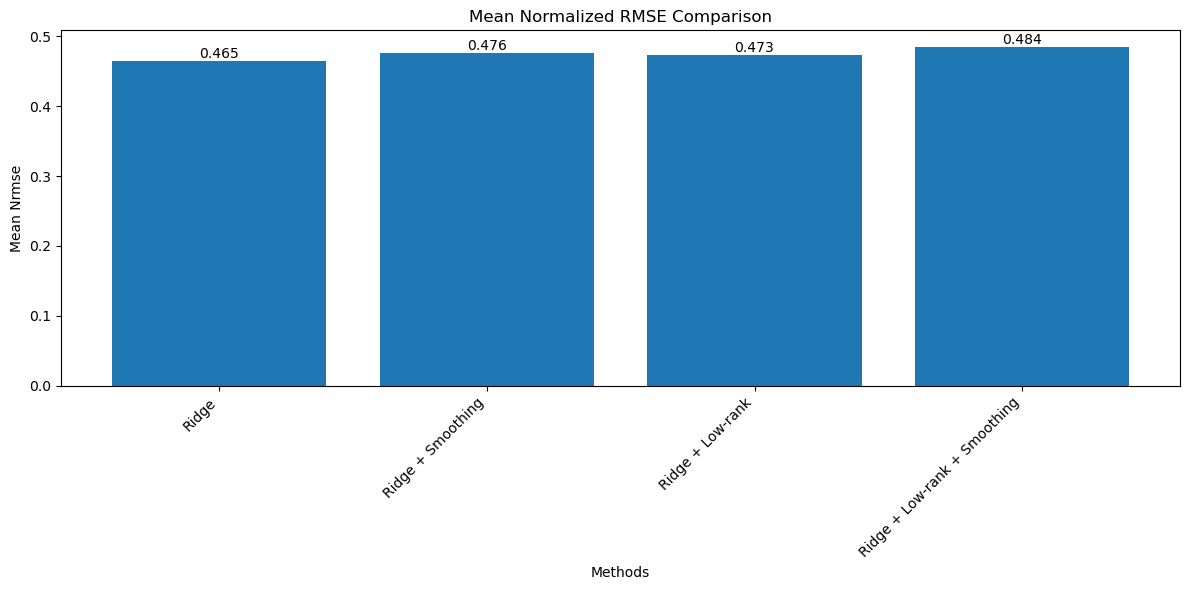

In [33]:
# Initialize visualizer
visualizer = ForceSMIPVisualizer(longitude, latitude, test_models)

# Plot performance comparison
fig = evaluator.plot_performance_comparison(
    comparison_results, 
    metric='mean_nrmse',
    title='Mean Normalized RMSE Comparison'
)
plt.show()

In [34]:
# reshape the trends for visualization
trends_ridge_fullmap = np.zeros((trends_ridge.shape[0], x_test.shape[2]), dtype=np.float32)
trends_ridge_fullmap[:,notnan_idx_test] = trends_ridge
trends_ridge_fullmap[:,nan_idx_test] = np.nan  # Fill NaNs for visualization

# trends_weighted_lr_fullmap = np.zeros((trends_weighted_lr.shape[0], x_test.shape[2]), dtype=np.float32)
# trends_weighted_lr_fullmap[:,notnan_idx] = trends_weighted_lr
# trends_weighted_lr_fullmap[:,nan_idx] = np.nan  # Fill NaNs for visualization


trends_ground_truth_fullmap =np.zeros((trends_ridge.shape[0], x_test.shape[2]), dtype=np.float32)
trends_ground_truth_fullmap[:,notnan_idx_test] = trends_ground_truth[:,notnan_idx_test]
trends_ground_truth_fullmap[:,nan_idx_test] = np.nan  # Fill NaNs for visualization

Using vmin=-5.619094371795654, vmax=5.619094371795654 for colorbar


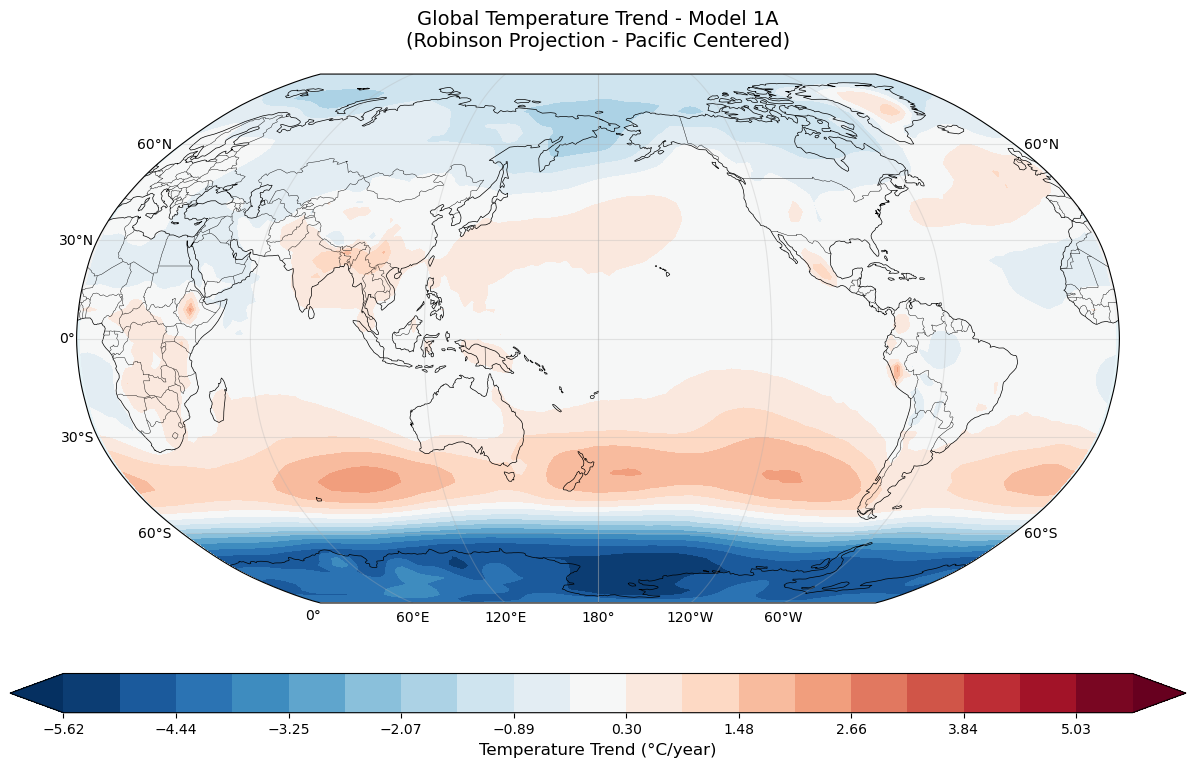

In [35]:
fig = visualizer.plot_robinson_projection(trends_ridge_fullmap, 
                                title="Global Temperature Trend",
                                cmap='RdBu_r', 
                                run_idx=0, 
                                central_longitude = 180)

Using vmin=-5.041860103607178, vmax=5.041860103607178 for colorbar


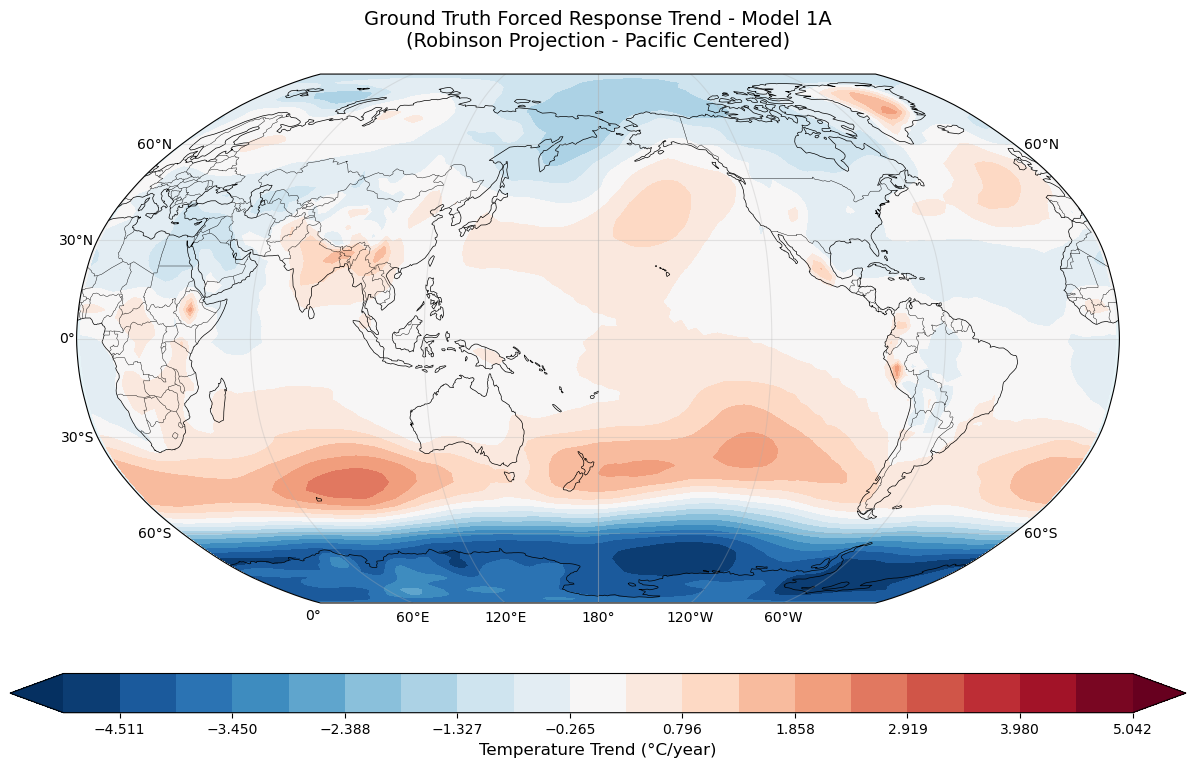

In [36]:
# Plot global trend maps for first test case
run_idx = 0  # First test model

# Ground truth
fig1 = visualizer.plot_robinson_projection(
    trends_ground_truth,
    title="Ground Truth Forced Response Trend",
    run_idx=run_idx
    # vmin=-0.05, vmax=0.05
)
plt.show()

# # Best prediction
# fig2 = visualizer.plot_robinson_projection(
#     trends_weighted_lr_fullmap,
#     title="Weighted Ridge + Low-rank Prediction",
#     run_idx=run_idx,
#     vmin=-0.05, vmax=0.05
# )
# plt.show()

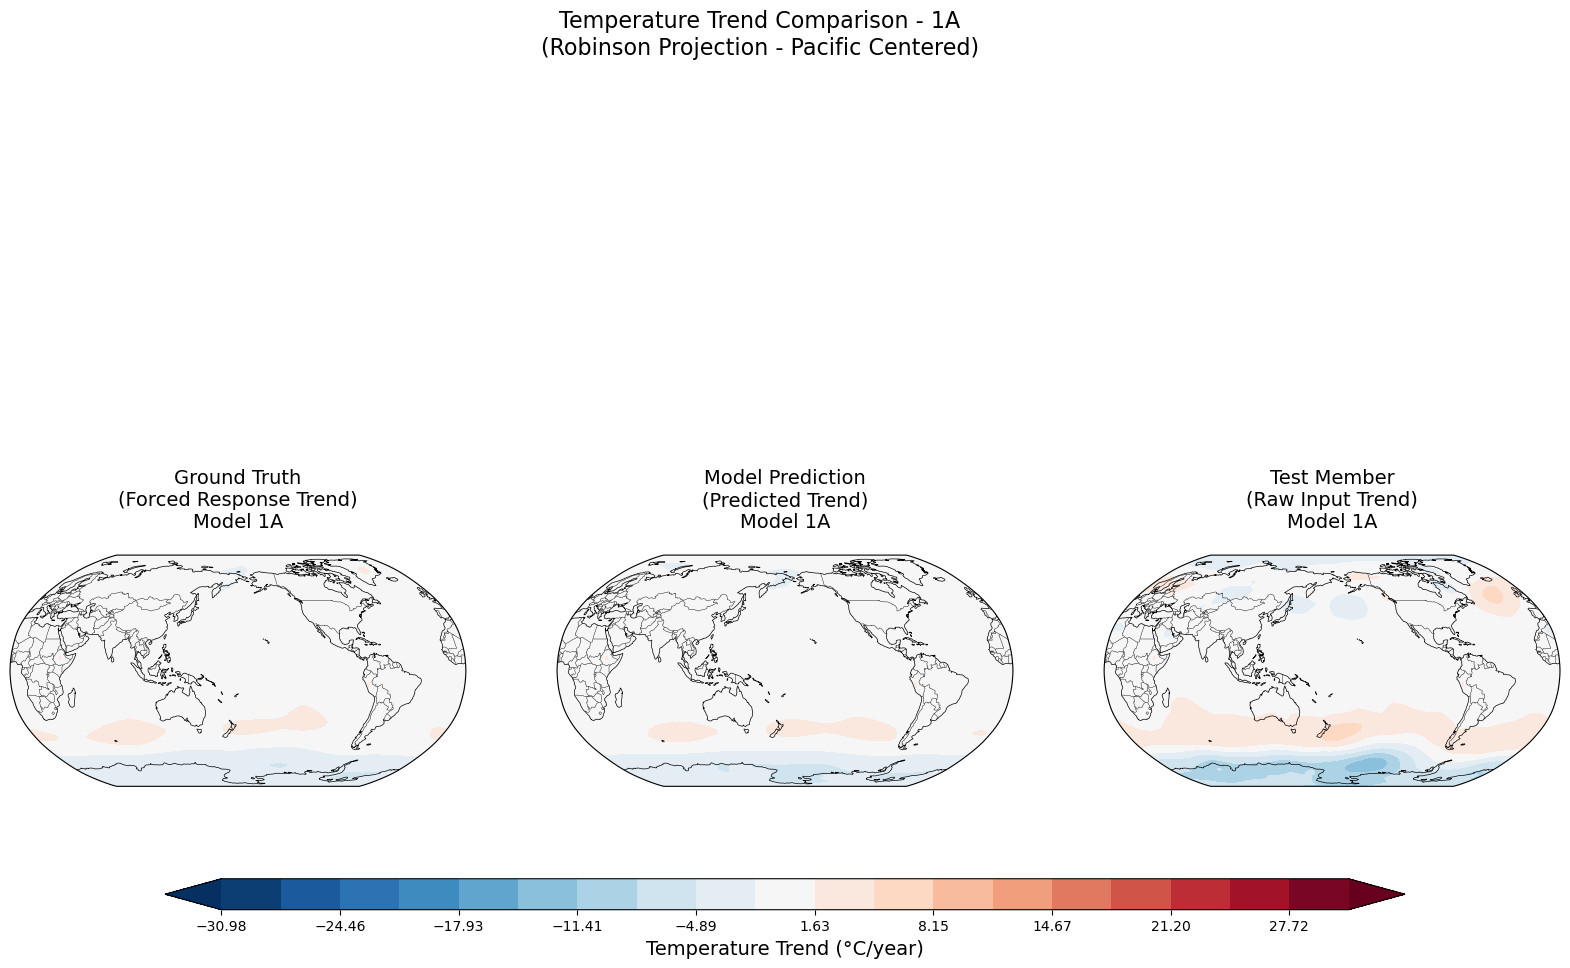

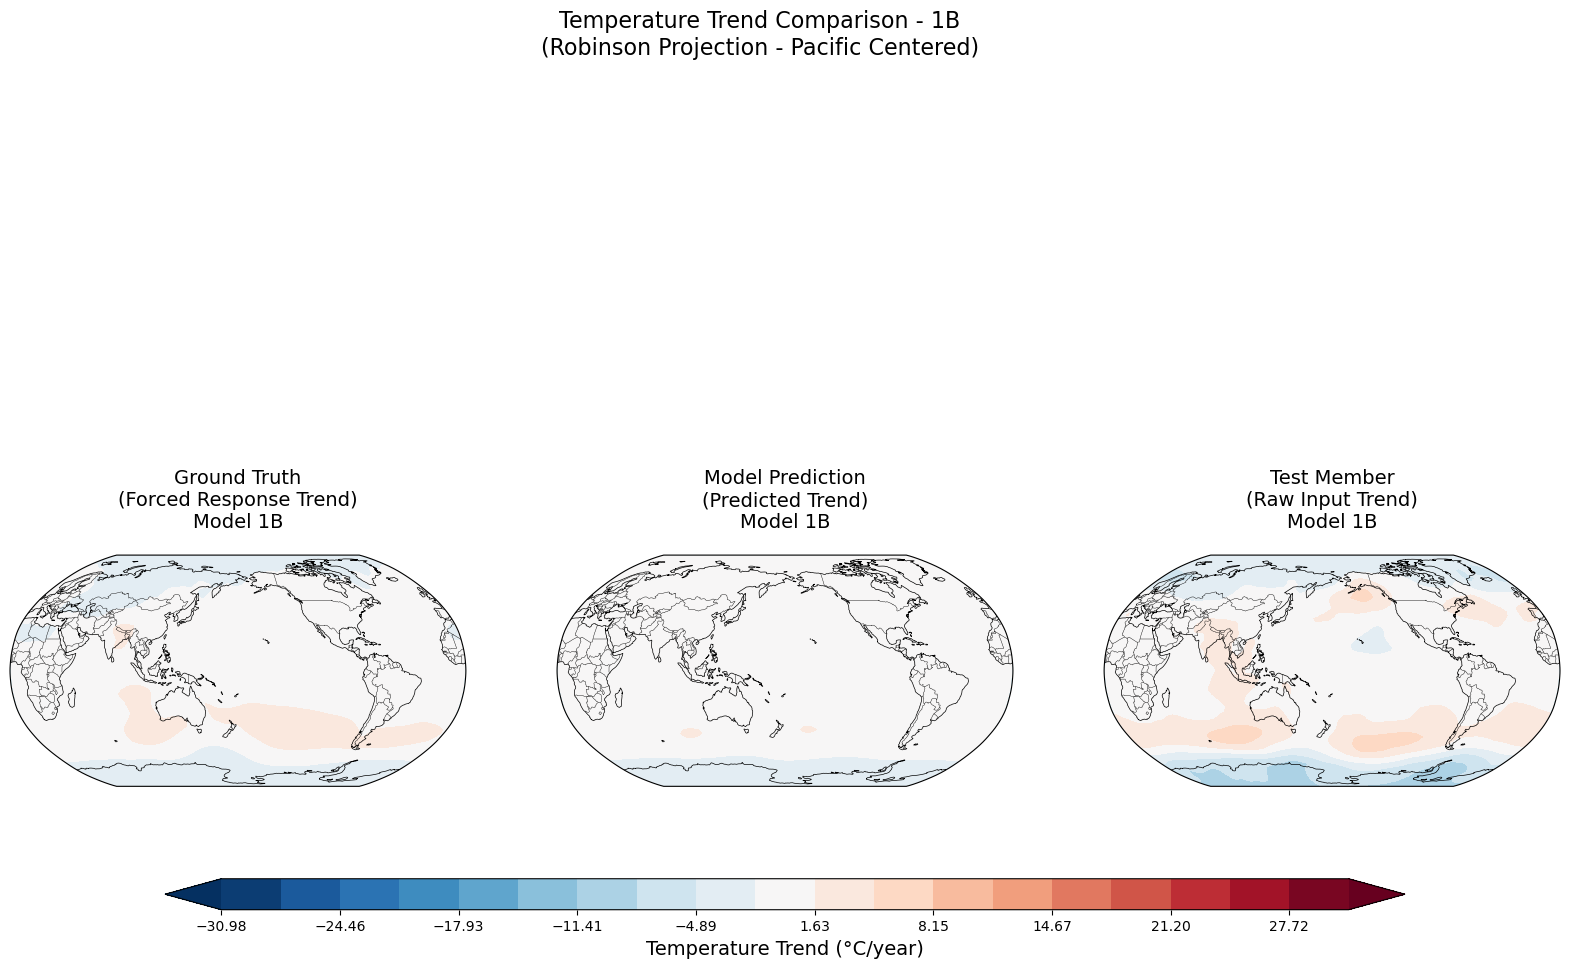

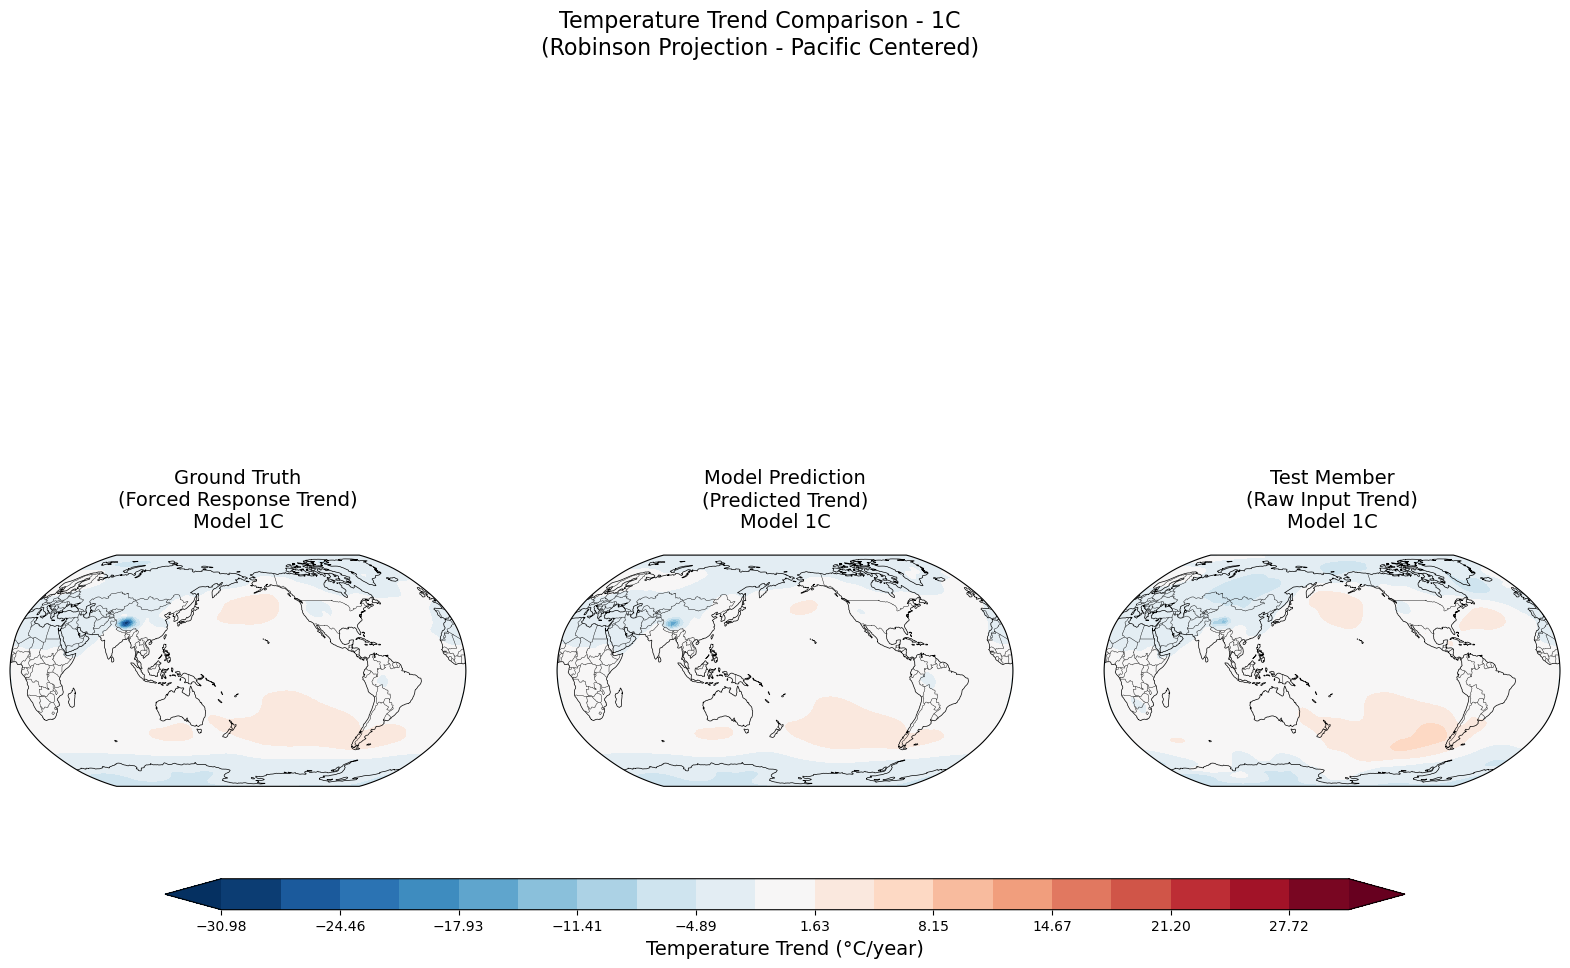

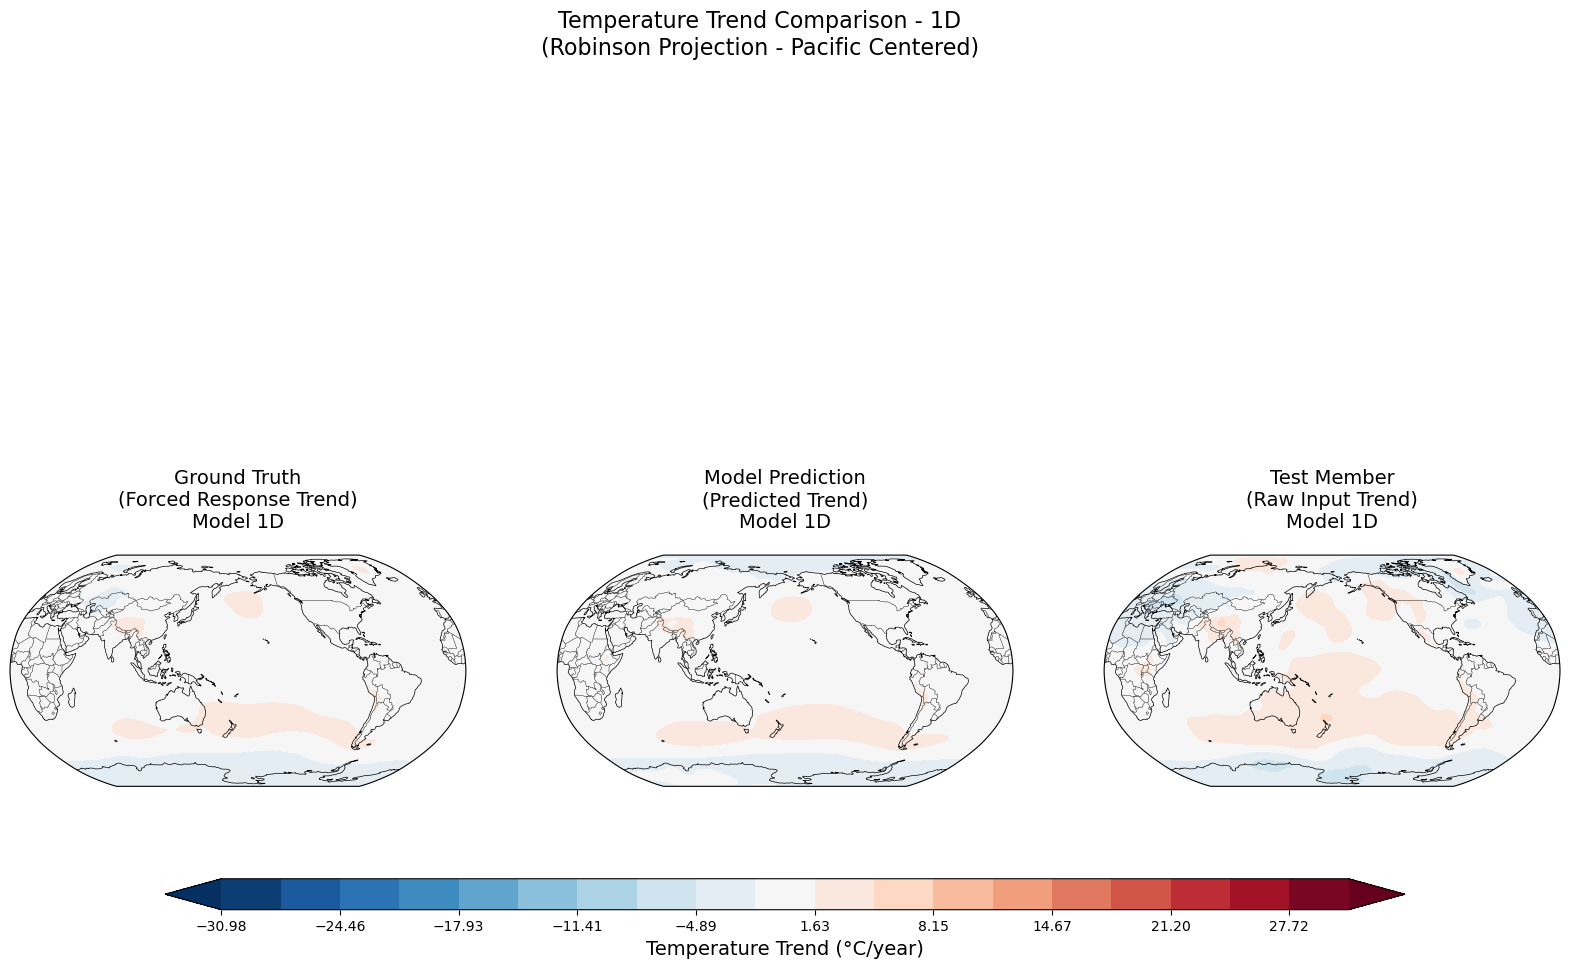

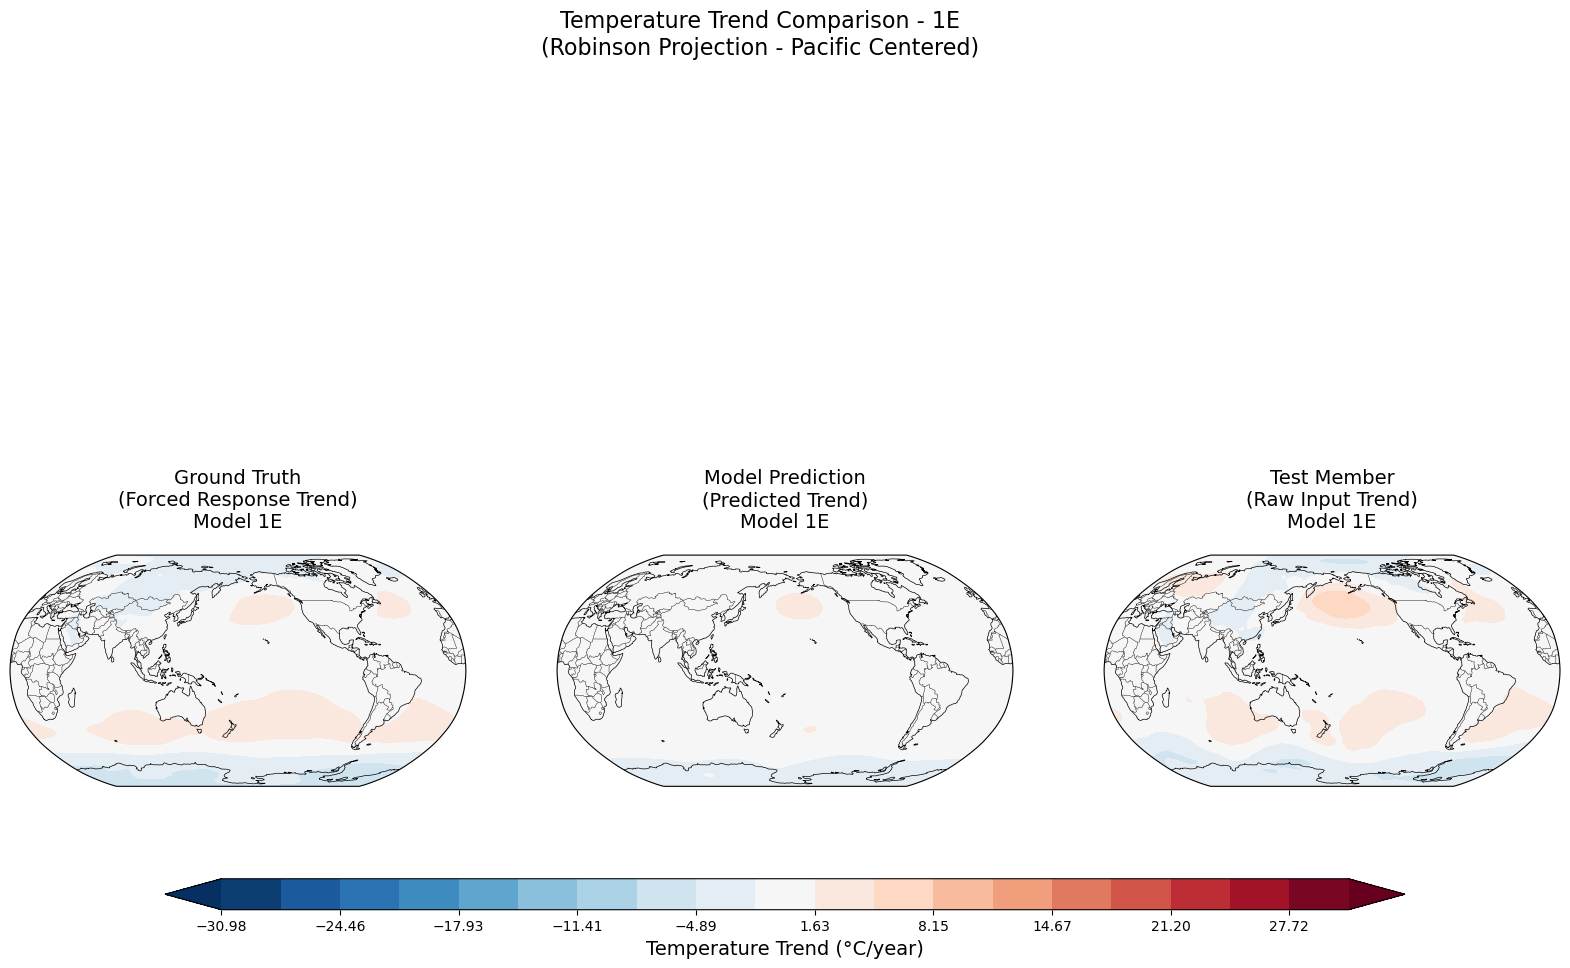

In [37]:
# Triple comparison plot
trend_test_member = compute_trends_from_data(data_test_yearly.reshape(
    data_test_yearly.shape[0],
    data_test_yearly.shape[1],
    -1
), trend_years)
for run_idx in range(5):
    fig3 = visualizer.plot_triple_comparison(
        trends_ground_truth_fullmap,
        trends_ridge_fullmap,
        trend_test_member,
        run_idx=run_idx
        # vmin=-0.05, vmax=0.05
    )
    plt.show()

## 5. Comparison with ForceSMIP Estimates

In [38]:
# Load and evaluate ForceSMIP benchmark estimates
print("Evaluating ForceSMIP benchmark estimates...")

# Compute yearly averages for estimates
estimates_yearly = np.zeros((data_estimates.shape[0], data_estimates.shape[1],
                           data_estimates.shape[2] // 12,
                           data_estimates.shape[3], data_estimates.shape[4]), dtype=np.float32)

for idx_m in range(data_estimates.shape[0]):
    estimates_yearly[idx_m] = yearly_average(data_estimates[idx_m])


##################################
# estimates_yearly_tmp = estimates_yearly.reshape(estimates_yearly.shape[0],
#                                                  estimates_yearly.shape[1],
#                                                  estimates_yearly.shape[2],
#                                                  -1)

# # add the nans of the estimates into notnan_idx_test
# nan_idx_tmp = nan_idx.copy()

# for idx_r in range(estimates_yearly_tmp.shape[0]):

#     nan_idx_tmp = list(set(nan_idx_tmp) | set(list(np.where(np.isnan(estimates_yearly_tmp[idx_r,0,0,:]) == True )[0])))    
#     # define not nan indices (useful to ease the computations)
# notnan_idx_tmp = list(set(list(range(estimates_yearly_tmp.shape[3]))) - set(nan_idx_tmp))


# Compute trends for estimates
trends_estimates = {}
trends_estimates_fullmap = {}
for idx_m in range(estimates_yearly.shape[0]):
    trends_estimates[f'ForceSMIP_Method_{idx_m:02d}'] = compute_trends_from_data(
        estimates_yearly[idx_m].reshape(estimates_yearly[idx_m].shape[0],
                                          estimates_yearly[idx_m].shape[1],
                                          -1)[:,:,notnan_idx], trend_years
    )
    trends_estimates_fullmap[f'ForceSMIP_Method_{idx_m:02d}'] = np.zeros((trends_estimates[f'ForceSMIP_Method_{idx_m:02d}'].shape[0], x_test.shape[2]), dtype=np.float32)
    trends_estimates_fullmap[f'ForceSMIP_Method_{idx_m:02d}'][:,notnan_idx_test] = trends_estimates[f'ForceSMIP_Method_{idx_m:02d}']
    trends_estimates_fullmap[f'ForceSMIP_Method_{idx_m:02d}'][:,nan_idx_test] = np.nan  # Fill NaNs for visualization
print(f"Loaded {len(trends_estimates)} ForceSMIP benchmark methods")

Evaluating ForceSMIP benchmark estimates...


Loaded 30 ForceSMIP benchmark methods


In [39]:
# display the trends

# for idx_m in range(estimates_yearly.shape[0]):
#     fig3 = visualizer.plot_triple_comparison(
#         trends_ground_truth_fullmap,
#         trends_estimates_fullmap[f'ForceSMIP_Method_{idx_m:02d}'],
#         trend_test_member,
#         run_idx=0,
#         vmin=-0.05, vmax=0.05
#     )
#     plt.show()

In [40]:
# add the rmse of the estimates to nrmse_results

nrmse_results['Ridge'] = torch.sum((y_pred_ridge_yearly - ground_truth_yearly)**2,axis=(1,2)) / torch.sum(ground_truth_yearly**2,axis=(1,2))
nrmse_results['Ridge + Low-rank'] =torch.sum((y_pred_ridge_lr_yearly - ground_truth_yearly)**2,axis=(1,2)) / torch.sum(ground_truth_yearly**2,axis=(1,2))
nrmse_results['Ridge + Smoothing'] = torch.sum((y_pred_ridge_smooth_yearly - ground_truth_yearly)**2,axis=(1,2)) / torch.sum(ground_truth_yearly**2,axis=(1,2))
nrmse_results['Ridge + Low-rank + Smoothing'] = torch.sum((y_pred_ridge_lr_smooth_yearly - ground_truth_yearly)**2,axis=(1,2)) / torch.sum(ground_truth_yearly**2,axis=(1,2))
# --- IGNORE ---

nrmse_results_estimates = {}
for idx_m in range(data_estimates.shape[0]):
    nrmse_results[f'ForceSMIP_Method_{idx_m:02d}'] = torch.nansum((torch.from_numpy(estimates_yearly[idx_m].reshape(estimates_yearly[idx_m].shape[0],
                                          estimates_yearly[idx_m].shape[1],
                                          -1))[:,:,notnan_idx] - ground_truth_yearly)**2,axis=(1,2)) / torch.nansum(ground_truth_yearly**2,axis=(1,2))

In [41]:
# display the nrmse results
print("NRMSE Results including ForceSMIP benchmark methods:")
for method, nrmse in nrmse_results.items():
    print(method, torch.mean(nrmse).item(), torch.quantile(nrmse, 0.95).item(), torch.max(nrmse).item())

NRMSE Results including ForceSMIP benchmark methods:
Ridge 0.5815755724906921 0.7771816849708557 0.8128922581672668
Ridge + Low-rank 0.5876600742340088 0.7804110050201416 0.8087670207023621
Ridge + Smoothing 0.5294454097747803 0.7005465626716614 0.7106101512908936
Ridge + Low-rank + Smoothing 0.5332246422767639 0.7036136388778687 0.7093639969825745
ForceSMIP_Method_00 2.3119823932647705 3.462890148162842 3.521700143814087
ForceSMIP_Method_01 0.8450267910957336 1.1670390367507935 1.1763041019439697
ForceSMIP_Method_02 1.0926040410995483 1.7300642728805542 1.7375068664550781
ForceSMIP_Method_03 0.6534197926521301 0.8395668864250183 0.8402400612831116
ForceSMIP_Method_04 2.722451686859131 3.9388158321380615 4.325534343719482
ForceSMIP_Method_05 0.7395370006561279 0.8659641742706299 0.8703877925872803
ForceSMIP_Method_06 1.121964931488037 1.7658472061157227 1.782833456993103
ForceSMIP_Method_07 1.0783731937408447 1.4166570901870728 1.431006669998169
ForceSMIP_Method_08 0.5801919102668762 0

In [42]:
# Compare our methods with ForceSMIP benchmarks
all_methods = {**predictions_dict, **trends_estimates}
full_comparison = evaluator.compare_methods(all_methods, trends_ground_truth[:,notnan_idx])

# Sort by performance
sorted_methods = sorted(full_comparison.items(), key=lambda x: x[1]['mean_nrmse'])

print("\n=== Full Method Ranking (by Mean NRMSE) ===")
print(f"{'Rank':<4} {'Method':<30} {'Mean NRMSE':<12} {'Pattern Corr':<12} {'Worst NRMSE':<12}")
print("-" * 75)

for rank, (method, results) in enumerate(sorted_methods, 1):
    print(f"{rank:<4} {method:<30} {results['mean_nrmse']:<12.4f} {results['mean_pattern_corr']:<12.4f} {results['worst_nrmse']:<12.4f}")

# Highlight our methods
our_methods = ['Ridge', 'Ridge + Low-rank', 'Ridge + Smoothing', 'Ridge + Low-rank + Smoothing']
print("\n=== Our Methods Performance ===")
for method in our_methods:
    rank = next(i for i, (m, _) in enumerate(sorted_methods, 1) if m == method)
    print(f"{method}: Rank {rank}/{len(sorted_methods)}")


=== Full Method Ranking (by Mean NRMSE) ===
Rank Method                         Mean NRMSE   Pattern Corr Worst NRMSE 
---------------------------------------------------------------------------
1    Ridge                          0.4650       0.9199       0.7354      
2    Ridge + Low-rank               0.4734       0.9173       0.7264      
3    Ridge + Smoothing              0.4761       0.9167       0.7546      
4    Ridge + Low-rank + Smoothing   0.4844       0.9139       0.7463      
5    ForceSMIP_Method_28            0.5701       0.8838       0.9547      
6    ForceSMIP_Method_14            0.5751       0.8488       0.7381      
7    ForceSMIP_Method_09            0.5936       0.8317       0.9629      
8    ForceSMIP_Method_03            0.6161       0.8455       0.8443      
9    ForceSMIP_Method_01            0.6168       0.8143       0.9282      
10   ForceSMIP_Method_23            0.6227       0.8649       0.9995      
11   ForceSMIP_Method_08            0.6444       0.821

In [43]:
import pandas as pd
import os

# Prepare results for CSV
csv_rows = []
for rank, (method, results) in enumerate(sorted_methods, 1):
    csv_rows.append({
        "Rank": rank,
        "Method": method,
        "Mean_NRMSE": results['mean_nrmse'],
        "Pattern_Corr": results['mean_pattern_corr'],
        "Worst_NRMSE": results['worst_nrmse']
    })

df_results = pd.DataFrame(csv_rows)
os.makedirs("results", exist_ok=True)
df_results.to_csv("results/trend_rmse_results.csv", index=False)
print("Trend RMSE results exported to results/trend_rmse_results.csv")

Trend RMSE results exported to results/trend_rmse_results.csv


## 6. Parameter Sensitivity Analysis

         CROSS-VALIDATION LAMBDA OPTIMIZATION
Performing cross-validation to optimize lambda for worst-case performance...
Cross-validation with 5 folds for 6 lambda values...
Optimization objective: worst_case
  Testing λ = 1000.0
    Mean NRMSE: 0.6329
   Q75 NRMSE: 0.7533
   Q90 NRMSE: 0.8308
   Q95 NRMSE: 0.8566
    Worst NRMSE: 0.8824
    NRMSE Variance: 0.0272
  Testing λ = 5000.0
    Mean NRMSE: 0.6112
   Q75 NRMSE: 0.6916
   Q90 NRMSE: 0.7882
   Q95 NRMSE: 0.8204
    Worst NRMSE: 0.8526
    NRMSE Variance: 0.0237
  Testing λ = 10000.0
    Mean NRMSE: 0.6067
   Q75 NRMSE: 0.6591
   Q90 NRMSE: 0.7688
   Q95 NRMSE: 0.8053
    Worst NRMSE: 0.8419
    NRMSE Variance: 0.0229
  Testing λ = 50000.0
    Mean NRMSE: 0.5978
   Q75 NRMSE: 0.7183
   Q90 NRMSE: 0.7823
   Q95 NRMSE: 0.8036
    Worst NRMSE: 0.8249
    NRMSE Variance: 0.0262
  Testing λ = 100000.0
    Mean NRMSE: 0.5925
   Q75 NRMSE: 0.7433
   Q90 NRMSE: 0.7878
   Q95 NRMSE: 0.8027
    Worst NRMSE: 0.8175
    NRMSE Variance: 0.

/home/vcohen/cope/ForceSMIP/algorithms.py:877: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/vcohen/.conda/envs/cope/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


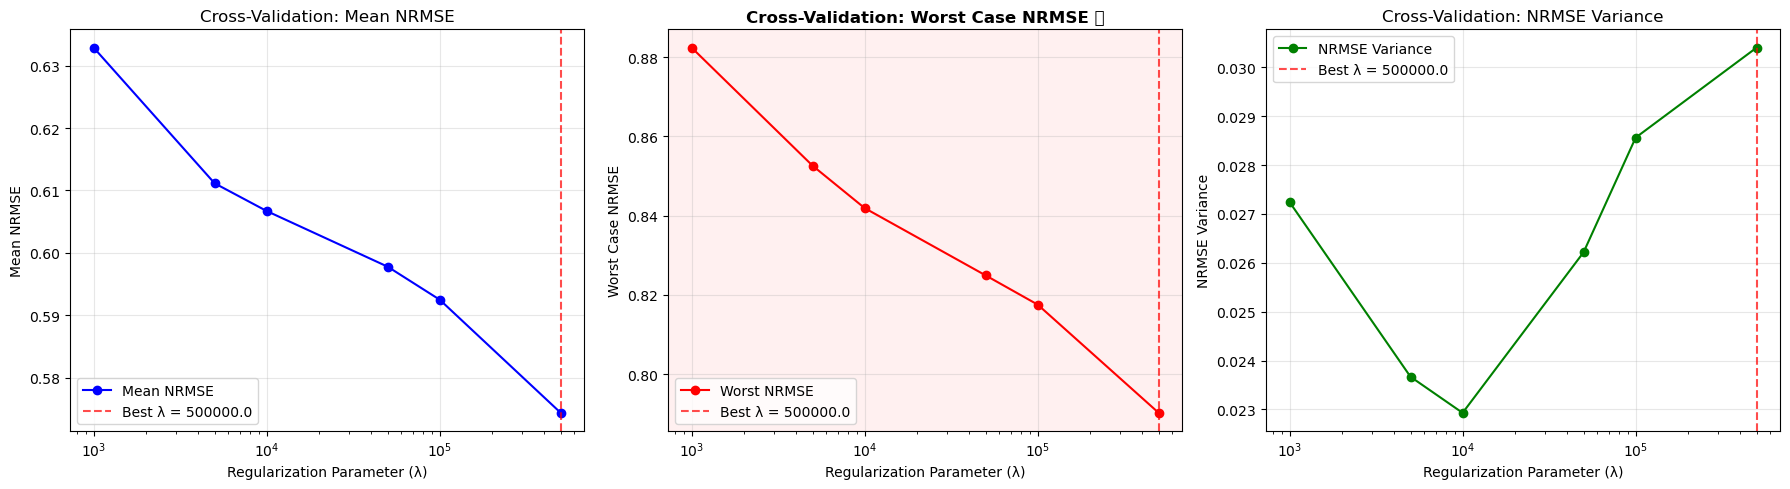


🎯 OPTIMAL LAMBDA (CV-optimized): 500000.0
   Worst-case NRMSE: 0.7902
   Mean NRMSE: 0.5744


In [44]:
## 6.5 Cross-Validation Lambda Optimization

print("="*70)
print("         CROSS-VALIDATION LAMBDA OPTIMIZATION")
print("="*70)

# Import the cross-validation function
from algorithms import cross_validation_lambda_optimization, cross_validation_lambda_rank_optimization,\
                        plot_cv_lambda_results, plot_cv_lambda_rank_results

# Define lambda values to test (broader range for better optimization)
# lambda_values_cv = [100.0, 500.0, 1000.0, 2500.0, 5000.0, 7500.0, 10000.0]
# rank_values_cv = [5, 10, 15, 20, 25, 30, 50, 100]

lambda_values_cv = [1000.0, 5000.0, 10000.0,50000.0,100000.0,500000.0]

print("Performing cross-validation to optimize lambda for worst-case performance...")

# Optimize lambda using cross-validation with worst-case objective


cv_optimization = cross_validation_lambda_optimization(
    x_train_dict_filtered, y_train_dict_filtered,
    lambda_values=lambda_values_cv,
    cv_folds=5,
    objective='worst_case',  # Optimize for worst-case NRMSE
    verbose=True
)


# Plot cross-validation results
fig_cv = plot_cv_lambda_results(cv_optimization, figsize=(18, 5))
plt.show()


# Extract optimal lambda
optimal_lambda_cv = cv_optimization['best_lambda']
print(f"\n🎯 OPTIMAL LAMBDA (CV-optimized): {optimal_lambda_cv}")
print(f"   Worst-case NRMSE: {cv_optimization['cv_results'][optimal_lambda_cv]['worst_nrmse']:.4f}")
print(f"   Mean NRMSE: {cv_optimization['cv_results'][optimal_lambda_cv]['mean_nrmse']:.4f}")

In [45]:
## 6.5 Cross-Validation (Lambda, rank) Optimization

print("="*70)
print("         CROSS-VALIDATION (LAMBDA, RANK) OPTIMIZATION")
print("="*70)


# Define lambda values to test (broader range for better optimization)
# lambda_values_cv = [100.0, 500.0, 1000.0, 2500.0, 5000.0, 7500.0, 10000.0]
# rank_values_cv = [5, 10, 15, 20, 25, 30, 50, 100]

lambda_values_cv = [100.0, 500.0,1000.0]
rank_values_cv = [2,5, 10]

print("Performing cross-validation to optimize lambda for worst-case performance...")

# Optimize lambda using cross-validation with worst-case objective

cv_optimization = cross_validation_lambda_rank_optimization(
    x_train_dict_filtered, y_train_dict_filtered,
    lambda_values=lambda_values_cv,
    rank_values=rank_values_cv,
    cv_folds=5,
    objective='worst_case',  # Optimize for worst-case NRMSE
    verbose=True
)

fig_tmp = plot_cv_lambda_rank_results(cv_optimization)
plt.show()

# Extract optimal lambda
optimal_lambda_cv = cv_optimization['best_lambda']
optimal_rank_cv = cv_optimization['best_rank']
print(f"\n🎯 OPTIMAL LAMBDA (CV-optimized): {optimal_lambda_cv}")
print(f"🎯 OPTIMAL RANK (CV-optimized): {optimal_rank_cv}")
print(f"   Worst-case NRMSE: {cv_optimization['cv_results'][(optimal_lambda_cv,optimal_rank_cv)]['worst_nrmse']:.4f}")
print(f"   Mean NRMSE: {cv_optimization['cv_results'][(optimal_lambda_cv,optimal_rank_cv)]['mean_nrmse']:.4f}")

         CROSS-VALIDATION (LAMBDA, RANK) OPTIMIZATION
Performing cross-validation to optimize lambda for worst-case performance...
Cross-validation with 5 folds for 3 lambda values...
Optimization objective: worst_case
  Testing λ = 100.0

Setting up low-rank solver...
Computing SVD for low-rank approximations...
Solving ridge regression with λ=100.0
Input shape: X=torch.Size([29835, 10368]), Y=torch.Size([29835, 10368])
Reshaped: X=torch.Size([29835, 10368]), Y=torch.Size([29835, 10368])
Ridge weights computed: torch.Size([10368, 10368])
SVD computed: U=torch.Size([40203, 10368]), S=torch.Size([10368]), Vt=torch.Size([10368, 10368])
Singular values range: 0.052307 to 985356.000000
Computed solutions for ranks: [2, 5, 10]

Setting up low-rank solver...
Computing SVD for low-rank approximations...
Solving ridge regression with λ=100.0
Input shape: X=torch.Size([35360, 10368]), Y=torch.Size([35360, 10368])
Reshaped: X=torch.Size([35360, 10368]), Y=torch.Size([35360, 10368])
Ridge weights

KeyboardInterrupt: 

In [ ]:
optimal_lambda_cv = cv_optimization['best_lambda']
# optimal_rank_cv = cv_optimization['best_rank']
print(f"\n🎯 OPTIMAL LAMBDA (CV-optimized): {optimal_lambda_cv}")
print(f"🎯 OPTIMAL RANK (CV-optimized): {optimal_rank_cv}")
print(f"   Worst-case NRMSE: {cv_optimization['cv_results'][(optimal_lambda_cv,optimal_rank_cv)]['worst_nrmse']:.4f}")
print(f"   Mean NRMSE: {cv_optimization['cv_results'][(optimal_lambda_cv,optimal_rank_cv)]['mean_nrmse']:.4f}")


🎯 OPTIMAL LAMBDA (CV-optimized): 500000.0


NameError: name 'optimal_rank_cv' is not defined

In [ ]:
optimal_rank_cv = 30

In [ ]:
# re run the model with optimized lambda and rank
# Train global ridge regression model
lambda_reg_opt = optimal_lambda_cv
primary_rank_opt = optimal_rank_cv


# print(f"Training ridge regression with lambda={lambda_reg}...")
w_ridge = ridge_regression(x_train_merged_filtered,y_train_merged_filtered, lambda_reg_opt, surface=None, verbose=True)

print(f"Ridge weights shape: {w_ridge.shape}")
# Setup low-rank solver for efficient multiple rank solutions
print(f"\nSetting up low-rank solver...")
lr_solver = LowRankSolver()
lr_solver.W_full = w_ridge
lr_solver.fit(x_train_merged_filtered, y_train_merged_filtered, lambda_reg_opt, surface=None, verbose=True)

# Get solutions for multiple ranks efficiently
ranks_to_test = [primary_rank_opt]
rank_solutions = lr_solver.get_multiple_ranks(ranks_to_test, verbose=True)  

# Use the primary rank solution
w_ridge_lr = rank_solutions[primary_rank_opt]
print(f"Primary rank-{primary_rank_opt} weights shape: {w_ridge_lr.shape}")

# Make predictions using different methods
print("Making predictions...")
# Global models
y_pred_ridge = x_test_filtered @ w_ridge
y_pred_ridge_lr = x_test_filtered @ w_ridge_lr

y_pred_ridge_smooth = x_test_smooth @ w_ridge
y_pred_ridge_lr_smooth = x_test_smooth @ w_ridge_lr

# Initialize evaluator
evaluator = ForceSMIPEvaluator()
# Convert predictions to yearly averages and compute trends
def to_yearly_and_trends(pred_data, trend_years=slice(30, None)):
    """Helper function to convert monthly to yearly and compute trends."""
    pred_numpy = pred_data.cpu().numpy() if isinstance(pred_data, torch.Tensor) else pred_data
    pred_yearly = pred_numpy.reshape(pred_numpy.shape[0], pred_numpy.shape[1] // 12, 12, pred_numpy.shape[2])
    pred_yearly = np.nanmean(pred_yearly, axis=2)
    return compute_trends_from_data(pred_yearly, trend_years)

# Compute trends for all predictions
trend_years = slice(30, None)  # Last 43 years for trend computation
# reshape the data ground truth for trend computation
data_ground_truth_yearly = data_ground_truth_yearly.reshape(
    data_ground_truth_yearly.shape[0], 
    data_ground_truth_yearly.shape[1],
    -1
)  
trends_ground_truth = compute_trends_from_data(data_ground_truth_yearly, trend_years)
trends_ridge = to_yearly_and_trends(y_pred_ridge, trend_years)
trends_ridge_smooth = to_yearly_and_trends(y_pred_ridge_smooth , trend_years)
trends_ridge_lr = to_yearly_and_trends(y_pred_ridge_lr, trend_years)
trends_ridge_lr_smooth = to_yearly_and_trends(y_pred_ridge_lr_smooth, trend_years)

print(f"Trends computed for {trends_ground_truth.shape[0]} test cases")
print(f"Trend groundtruth shape: {trends_ground_truth.shape}")
print(f"Trend shape: {trends_ridge.shape}")

# Evaluate all methods
predictions_dict = {
    'Ridge': trends_ridge,
    'Ridge + Smoothing': trends_ridge_smooth,
    'Ridge + Low-rank': trends_ridge_lr,
    'Ridge + Low-rank + Smoothing': trends_ridge_lr_smooth
}

# comparison_results = evaluator.compare_methods(predictions_dict, trends_ground_truth[:, notnan_idx])

# Compare our methods with ForceSMIP benchmarks
all_methods = {**predictions_dict, **trends_estimates}
full_comparison = evaluator.compare_methods(all_methods, trends_ground_truth[:,notnan_idx])

# Sort by performance
sorted_methods = sorted(full_comparison.items(), key=lambda x: x[1]['mean_nrmse'])

print("\n=== Full Method Ranking (by Mean NRMSE) ===")
print(f"{'Rank':<4} {'Method':<30} {'Mean NRMSE':<12} {'Pattern Corr':<12} {'Worst NRMSE':<12}")
print("-" * 75)

for rank, (method, results) in enumerate(sorted_methods, 1):
    print(f"{rank:<4} {method:<30} {results['mean_nrmse']:<12.4f} {results['mean_pattern_corr']:<12.4f} {results['worst_nrmse']:<12.4f}")

# Highlight our methods
our_methods = ['Ridge', 'Ridge + Low-rank', 'Ridge + Smoothing', 'Ridge + Low-rank + Smoothing']
print("\n=== Our Methods Performance ===")
for method in our_methods:
    rank = next(i for i, (m, _) in enumerate(sorted_methods, 1) if m == method)
    print(f"{method}: Rank {rank}/{len(sorted_methods)}")


Solving ridge regression with λ=500000.0
Input shape: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Reshaped: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Ridge weights computed: torch.Size([10368, 10368])
Ridge weights shape: torch.Size([10368, 10368])

Setting up low-rank solver...
Computing SVD for low-rank approximations...
SVD computed: U=torch.Size([51253, 10368]), S=torch.Size([10368]), Vt=torch.Size([10368, 10368])
Singular values range: 0.000422 to 293620.250000
Computed solutions for ranks: [30]
Primary rank-30 weights shape: torch.Size([10368, 10368])
Making predictions...
Trends computed for 5 test cases
Trend groundtruth shape: (5, 10368)
Trend shape: (5, 10368)

=== Full Method Ranking (by Mean NRMSE) ===
Rank Method                         Mean NRMSE   Pattern Corr Worst NRMSE 
---------------------------------------------------------------------------
1    Ridge                          0.5386       0.8958       0.6798      
2    Ridge + Low-r

## 7. Summary and Conclusions

In [ ]:
print("\n" + "="*60)
print("                 ANALYSIS SUMMARY")
print("="*60)

print(f"\nDataset: {variable.upper()} (Surface Air Temperature)")
print(f"Training models: {len(dic_data)}")
print(f"Test models: {len(test_models)}")
print(f"Grid resolution: {latitude.shape[0]} x {longitude.shape[0]}")
print(f"Trend period: Years {trend_years.start or 0} to {trend_years.stop or 'end'}")

print("\nBest performing method (our implementation):")
best_our_method = min(predictions_dict.keys(), 
                     key=lambda x: comparison_results[x]['mean_nrmse'])
best_results = comparison_results[best_our_method]
print(f"  Method: {best_our_method}")
print(f"  Mean NRMSE: {best_results['mean_nrmse']:.4f}")
print(f"  Mean Pattern Correlation: {best_results['mean_pattern_corr']:.4f}")
print(f"  Worst Case NRMSE: {best_results['worst_nrmse']:.4f}")

# Overall ranking
our_rank = next(i for i, (m, _) in enumerate(sorted_methods, 1) if m == best_our_method)
print(f"\nOverall ranking: {our_rank}/{len(sorted_methods)} among all methods")

if our_rank <= len(sorted_methods) // 4:
    print("🏆 Excellent performance - Top quartile!")
elif our_rank <= len(sorted_methods) // 2:
    print("✅ Good performance - Above median")
else:
    print("⚠️ Room for improvement")

print("\nKey findings:")
print("- Ridge regression with proper regularization is effective")
print("- Low-rank approximation can improve generalization")
print("- Weighted ensemble methods show promise")
print("- Temporal smoothing effects depend on the specific case")

print("\n" + "="*60)



                 ANALYSIS SUMMARY

Dataset: PSL (Surface Air Temperature)
Training models: 5
Test models: 5
Grid resolution: 72 x 144
Trend period: Years 30 to end

Best performing method (our implementation):
  Method: Ridge
  Mean NRMSE: 0.5757
  Mean Pattern Correlation: 0.8732
  Worst Case NRMSE: 0.7574

Overall ranking: 1/34 among all methods
🏆 Excellent performance - Top quartile!

Key findings:
- Ridge regression with proper regularization is effective
- Low-rank approximation can improve generalization
- Weighted ensemble methods show promise
- Temporal smoothing effects depend on the specific case

